<a href="https://colab.research.google.com/github/dudaoliani/MVP-CEP-Milk-Quality-Prediction/blob/main/MVP.FINAL_l_Milky_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MVP CEP**

**Maria Eduarda Moreno Oliani - 231013458**

**Introdução:**

Este MVP aplica o ciclo DMAMC ao monitoramento da qualidade do leite, usando como base teórica o livro do Montgomery. O dataset contém 1059 amostras com 8 atributos físico-químicos (pH, temperatura, turbidez, gordura...) e uma variável resposta categórica (Grade: low, medium, high). A variável escolhida como CTQ (Critical to Quality) para as cartas de controle é o pH, por ser contínua, mensurável e diretamente ligada à qualidade microbiológica do leite.

In [14]:
#BLOCO 1 — Imports e configuração
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

**Etapa 1: Definir e Medir**

A primeira etapa do DMAMC é Definir e Medir. Aqui carregamos o dataset e geramos a estatística descritiva, isso serve como linha de base do processo antes de qualquer análise.

A separação por pH é essencial (~5,70 para low, ~6,73 para medium, ~6,80 para high), apresentar apenas a média geral esconderia essa heterogeneidade, que é a principal característica do dataset e motivará todas as decisões posteriores.

ETAPA 1: DEFINIR E MEDIR
Using Colab cache for faster access to the 'milkquality' dataset.

Dimensões: 1059 amostras x 8 variáveis

Distribuição de Grade:
Grade
low       429
medium    374
high      256
Name: count, dtype: int64

Estatísticas de pH por categoria de qualidade:
        count    mean     std  min  25%  50%  75%  max
Grade                                                 
high    256.0  6.6926  0.1088  6.5  6.6  6.7  6.8  6.8
low     429.0  6.5886  2.1947  3.0  4.7  6.8  8.6  9.5
medium  374.0  6.6350  0.1309  6.4  6.5  6.6  6.8  6.8


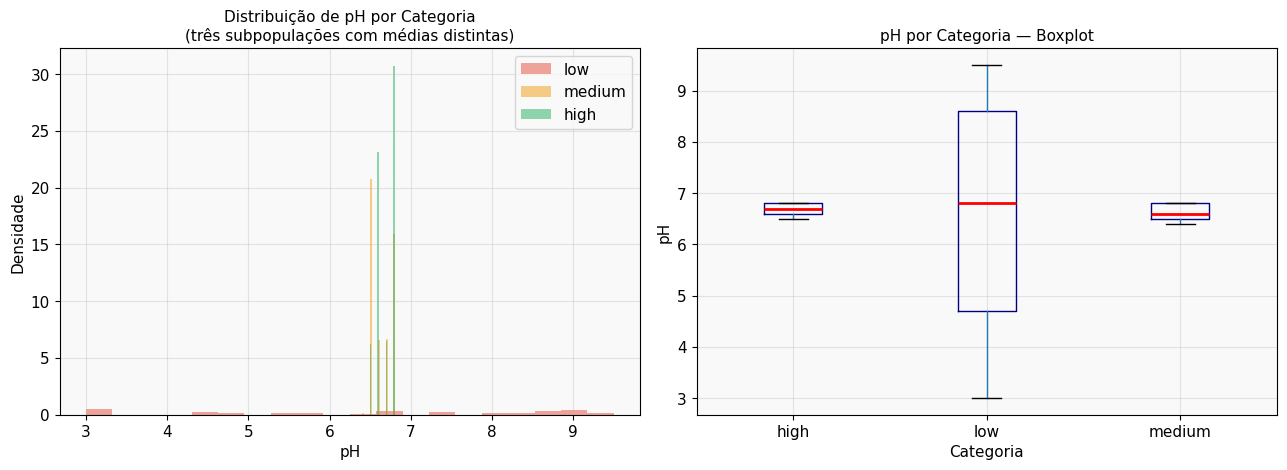

[Fig. 1 salva]


In [10]:
# Separadas por categoria de qualidade, expondo a heterogeneidade

print("=" * 70)
print("ETAPA 1: DEFINIR E MEDIR")
print("=" * 70)

path = kagglehub.dataset_download("cpluzshrijayan/milkquality")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"\nDimensões: {df.shape[0]} amostras x {df.shape[1]} variáveis")
print(f"\nDistribuição de Grade:\n{df['Grade'].value_counts()}")

# Estatísticas por categoria: as médias de pH são distintas entre grupos,
# o que indica que o dataset é uma mistura de subpopulações.
# Esse achado justifica a estratificação nas cartas de controle (Bloco 6).
print("\nEstatísticas de pH por categoria de qualidade:")
print(df.groupby('Grade')['pH'].describe().round(4))

cores_cat = {'low': '#e74c3c', 'medium': '#f39c12', 'high': '#27ae60'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma sobreposto: mostra as três distribuições de pH lado a lado.
# Cada grupo tem uma moda distinta — confirmando que não há um único
# processo homogêneo, mas três populações com comportamentos diferentes.
for grade, cor in cores_cat.items():
    sub = df[df['Grade'] == grade]['pH']
    axes[0].hist(sub, bins=20, alpha=0.5, color=cor, label=grade, density=True)
axes[0].set_title(
    "Distribuição de pH por Categoria\n"
    "(três subpopulações com médias distintas)", fontsize=11)
axes[0].set_xlabel("pH")
axes[0].set_ylabel("Densidade")
axes[0].legend()

# Boxplot: compara mediana, dispersão e outliers entre categorias.
# A categoria 'low' apresenta maior dispersão e mediana bem mais baixa.
df.boxplot(column='pH', by='Grade', ax=axes[1],
           boxprops=dict(color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title("pH por Categoria — Boxplot", fontsize=11)
axes[1].set_xlabel("Categoria")
axes[1].set_ylabel("pH")
plt.suptitle("")
plt.tight_layout()
plt.savefig("fig1_pH_por_categoria.png", dpi=150)
plt.show()
print("[Fig. 1 salva]")

**Etapa 2 e 3: Analisar e Melhorar**

A etapa Analisar tem como objetivo identificar quais variáveis mais influenciam a qualidade do leite, o equivalente ao Diagrama de Causa e Efeito do Montgomery. Foi construída uma matriz de correlação entre as features do processo (sem incluir o rótulo de qualidade como variável numérica no heatmap, o que inflaria artificialmente as correlações). Além disso, calculei separadamente a correlação de cada feature com o target para ter um ranking claro de relevância.

Na etapa Melhorar, treinei um classificador Random Forest para prever a categoria de qualidade do leite e extraí a importância de cada atributo, funcionando como um Diagrama de Pareto das variáveis de processo. Utilizei validação cruzada com 5 folds para garantir que os resultados não são dependentes de um único split. A acurácia próxima de 100% em todas as folds é explicada pela origem sintética do dataset: as variáveis foram geradas com regras determinísticas simples, de forma que as importâncias refletem a estrutura de geração dos dados, não necessariamente relações causais de um processo real. Ainda assim, o ranking de importâncias é válido como priorização de CTQs para fins deste MVP.


ETAPA 2: ANALISAR — Matriz de Correlação

Correlação de cada variável com Grade (target):
Fat           0.151
Odor          0.150
pH            0.029
Taste         0.026
Colour       -0.057
Turbidity    -0.154
Temprature   -0.418
Name: Grade_Num, dtype: float64


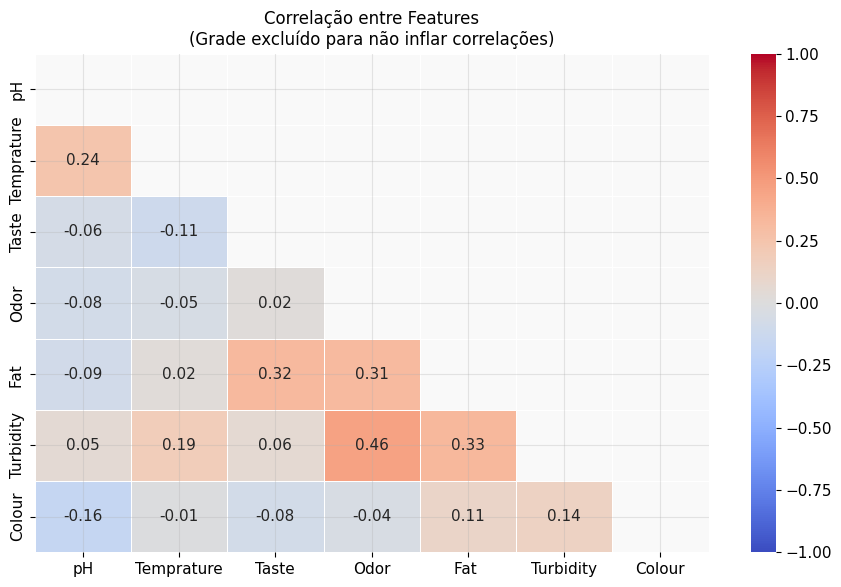

[Fig. 2 salva]

ETAPA 3: MELHORAR — Importância de Variáveis (Random Forest)

Classification report (hold-out 20%):
              precision    recall  f1-score   support

         low       1.00      0.99      0.99        86
      medium       1.00      1.00      1.00        75
        high       0.98      1.00      0.99        51

    accuracy                           1.00       212
   macro avg       0.99      1.00      0.99       212
weighted avg       1.00      1.00      1.00       212

Acurácia por fold (CV-5): ['0.991', '1.000', '1.000', '1.000', '0.991']
Média: 0.996 ± 0.005

Acurácia ≈ 100% em todas as folds.
O dataset é sintético com regras determinísticas — as importâncias
de variáveis refletem a estrutura de geração dos dados e são usadas
apenas como priorização de CTQs, não como análise de causa-raiz.


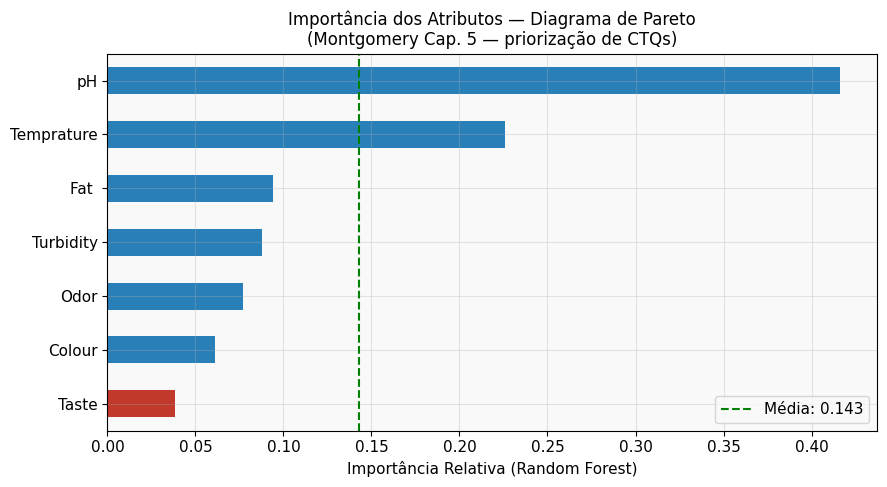


[Fig. 3 salva] CTQ confirmada: PH


In [18]:
# Grade_Num é criado apenas para calcular correlações com o target

print("\n" + "=" * 70)
print("ETAPA 2: ANALISAR — Matriz de Correlação")
print("=" * 70)

grade_map = {'low': 0, 'medium': 1, 'high': 2}
df['Grade_Num'] = df['Grade'].map(grade_map)

# Ranking de correlação de cada feature com o target
print("\nCorrelação de cada variável com Grade (target):")
print(df.drop(columns='Grade').corr(numeric_only=True)['Grade_Num']
        .drop('Grade_Num').sort_values(ascending=False).round(3))

# Heatmap apenas entre features (sem Grade_Num):
# exibe as relações entre variáveis de processo sem contaminação
# pelo rótulo codificado numericamente.
features_para_corr = df.drop(columns=['Grade', 'Grade_Num'])
fig, ax = plt.subplots(figsize=(9, 6))
corr = features_para_corr.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title(
    "Correlação entre Features\n"
    "(Grade excluído para não inflar correlações)", fontsize=12)
plt.tight_layout()
plt.savefig("fig2_correlacao_features.png", dpi=150)
plt.show()
print("[Fig. 2 salva]")

# Random Forest como Diagrama de Pareto (Montgomery Cap. 5).
# Validação cruzada garante que os resultados não dependem de um
print("\n" + "=" * 70)
print("ETAPA 3: MELHORAR — Importância de Variáveis (Random Forest)")
print("=" * 70)

X = df.drop(columns=['Grade', 'Grade_Num'])
y = df['Grade_Num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\nClassification report (hold-out 20%):")
print(classification_report(y_test, y_pred,
                             target_names=['low', 'medium', 'high']))

# Validação cruzada com 5 folds:
# acurácia ≈ 100% em todas as folds descarta a hipótese de overfitting
# em um único split — o dataset é estruturalmente determinístico.
cv_scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print(f"Acurácia por fold (CV-5): {[f'{s:.3f}' for s in cv_scores]}")
print(f"Média: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(
    "\nAcurácia ≈ 100% em todas as folds."
    "\nO dataset é sintético com regras determinísticas — as importâncias"
    "\nde variáveis refletem a estrutura de geração dos dados e são usadas"
    "\napenas como priorização de CTQs, não como análise de causa-raiz.")

# Gráfico de importâncias: funciona como Diagrama de Pareto,
# mostrando quais variáveis mais contribuem para a classificação de qualidade.
# A variável mais importante (em vermelho) confirma a CTQ escolhida.
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#c0392b' if imp == importances.max() else '#2980b9'
          for imp in importances]
importances.plot(kind='barh', ax=ax, color=colors[::-1])
ax.axvline(importances.mean(), color='green', linestyle='--',
           label=f'Média: {importances.mean():.3f}')
ax.set_title(
    "Importância dos Atributos — Diagrama de Pareto\n"
    "(Montgomery Cap. 5 — priorização de CTQs)", fontsize=12)
ax.set_xlabel("Importância Relativa (Random Forest)")
ax.legend()
plt.tight_layout()
plt.savefig("fig3_importancia_variaveis.png", dpi=150)
plt.show()
print(f"\n[Fig. 3 salva] CTQ confirmada: {importances.idxmax().upper()}")

**Etapa 4: Controlar (Pressuposto de Normalidade):**

Antes de construir qualquer carta de controle, Montgomery exige a verificação do pressuposto de normalidade, sem isso, a interpretação de Cp e Cpk é inválida. Usamos o teste de Shapiro-Wilk, recomendado pelo próprio Montgomery no Capítulo 8, complementado por um Q-Q Plot e um histograma com curva normal ajustada.
Se o p-valor for maior que 0,05, não rejeitamos a hipótese de normalidade e podemos prosseguir com segurança.

O teste rejeita normalidade em todos os casos. A inspeção visual dos Q-Q plots revela a causa: o pH no dataset assume apenas valores discretos e arredondados (6,5 — 6,6 — 6,7 — 6,8...), gerando o padrão de degraus horizontais nos gráficos em vez de pontos aderentes à reta de referência. Essa é uma limitação estrutural do dataset sintético. Em um processo real de medição contínua, o pH não assumiria valores assim. Para fins das cartas de controle e dos índices de capacidade, prossegui com a aproximação normal, que é o procedimento padrão do Montgomery quando a discretização é fina o suficiente para não distorcer os limites ±3σ.


ETAPA 4: CONTROLAR — Diagnóstico de Normalidade
Ref.: Montgomery Cap. 8

Shapiro-Wilk — dados completos:
  W = 0.8346 | p = 0.000000 → NÃO-NORMAL ✗

Shapiro-Wilk por categoria:
  high     (n=256)  W=0.7805  p=0.0000  → NÃO-NORMAL ✗
  medium   (n=374)  W=0.7758  p=0.0000  → NÃO-NORMAL ✗
  low      (n=429)  W=0.8915  p=0.0000  → NÃO-NORMAL ✗

  Causa identificada nos Q-Q plots: pH assume apenas valores
  discretos e arredondados — padrão de degraus horizontais nos gráficos.
  Limitação estrutural do dataset sintético.
  Procedimento: aproximação normal (Montgomery Cap. 8),
  válida quando a discretização é fina e não distorce os limites ±3σ.


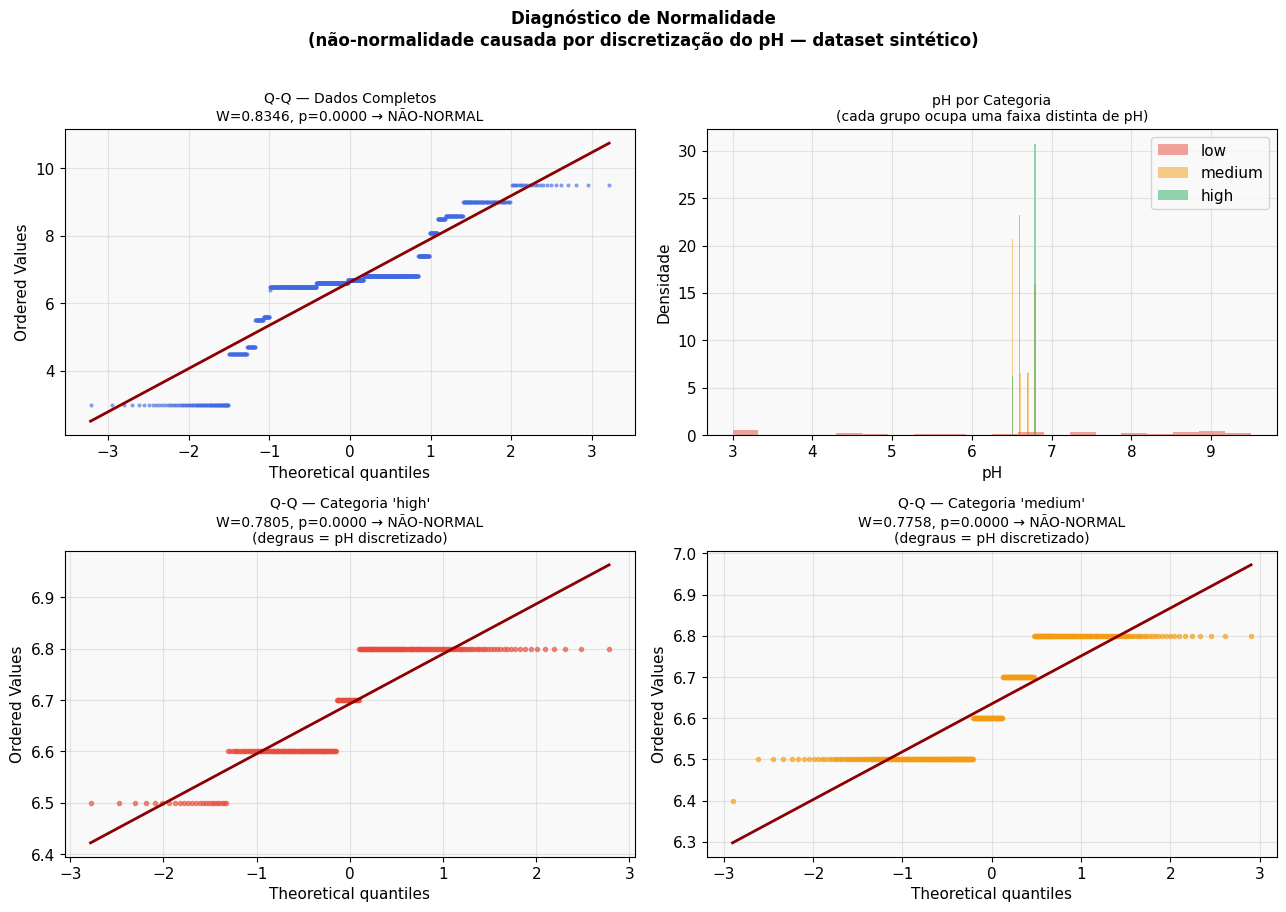

[Fig. 4 salva]


In [19]:
print("\n" + "=" * 70)
print("ETAPA 4: CONTROLAR — Diagnóstico de Normalidade")
print("Ref.: Montgomery Cap. 8")
print("=" * 70)

df_cep = df.copy().reset_index(drop=True)

# Shapiro-Wilk nos dados completos
print("\nShapiro-Wilk — dados completos:")
amostra_sw = df_cep['pH'].sample(n=min(len(df_cep), 5000), random_state=42)
stat_sw, p_sw = stats.shapiro(amostra_sw)
print(f"  W = {stat_sw:.4f} | p = {p_sw:.6f}"
      f" → {'NÃO-NORMAL ✗' if p_sw < 0.05 else 'Normal ✓'}")

# Shapiro-Wilk por categoria
# Rejeição em todas as categorias — causa identificada nos Q-Q plots:
# pH discretizado, não distribuição assimétrica ou bimodal interna.
print("\nShapiro-Wilk por categoria:")
normalidade_por_grade = {}
for grade in ['high', 'medium', 'low']:
    sub = df_cep[df_cep['Grade'] == grade]['pH']
    w, p = stats.shapiro(sub)
    normal = p > 0.05
    normalidade_por_grade[grade] = normal
    print(f"  {grade:8s} (n={len(sub):3d})  W={w:.4f}  p={p:.4f}"
          f"  → {'Normal ✓' if normal else 'NÃO-NORMAL ✗'}")

print(
    "\n  Causa identificada nos Q-Q plots: pH assume apenas valores"
    "\n  discretos e arredondados — padrão de degraus horizontais nos gráficos."
    "\n  Limitação estrutural do dataset sintético."
    "\n  Procedimento: aproximação normal (Montgomery Cap. 8),"
    "\n  válida quando a discretização é fina e não distorce os limites ±3σ.")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Q-Q dados completos: afastamento da reta por mistura de grupos
# e discretização simultâneos
stats.probplot(df_cep['pH'], dist="norm", plot=axes[0, 0])
axes[0, 0].set_title(
    f"Q-Q — Dados Completos\n"
    f"W={stat_sw:.4f}, p={p_sw:.4f} → NÃO-NORMAL", fontsize=10)
axes[0, 0].get_lines()[0].set(color='royalblue', markersize=2, alpha=0.5)
axes[0, 0].get_lines()[1].set(color='darkred', linewidth=2)

# Histograma por categoria: mostra a separação entre grupos
# e confirma que cada categoria tem sua própria faixa de pH
for grade, cor in cores_cat.items():
    sub = df_cep[df_cep['Grade'] == grade]['pH']
    axes[0, 1].hist(sub, bins=20, alpha=0.5, color=cor, label=grade, density=True)
axes[0, 1].set_title(
    "pH por Categoria\n(cada grupo ocupa uma faixa distinta de pH)", fontsize=10)
axes[0, 1].set_xlabel("pH")
axes[0, 1].set_ylabel("Densidade")
axes[0, 1].legend()

# Q-Q por categoria (high e medium): degraus horizontais evidenciam
# a discretização do pH — não assimetria ou bimodalidade interna
for i, grade in enumerate(['high', 'medium']):
    sub = df_cep[df_cep['Grade'] == grade]['pH']
    w_s, p_s = stats.shapiro(sub)
    stats.probplot(sub, dist="norm", plot=axes[1, i])
    axes[1, i].set_title(
        f"Q-Q — Categoria '{grade}'\n"
        f"W={w_s:.4f}, p={p_s:.4f} → NÃO-NORMAL\n"
        f"(degraus = pH discretizado)", fontsize=10)
    cor_lista = list(cores_cat.values())
    axes[1, i].get_lines()[0].set(color=cor_lista[i], markersize=3, alpha=0.6)
    axes[1, i].get_lines()[1].set(color='darkred', linewidth=2)

plt.suptitle(
    "Diagnóstico de Normalidade\n"
    "(não-normalidade causada por discretização do pH — dataset sintético)",
    fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("fig4_normalidade.png", dpi=150, bbox_inches='tight')
plt.show()
print("[Fig. 4 salva]")

**Etapa 4: Cartas de Controle X e MR estratificadas (Fase I e II)**

Foram construídas cartas de controle individuais X e MR para cada categoria de qualidade. Essa estratificação é necessária porque cada categoria representa um processo com pH médio e variabilidade distintos, monitorá-los conjuntamente resultaria em limites de controle que não representam nenhum dos três grupos. N

Na Fase I, usamos os primeiros 60% das observações de cada categoria para estimar a linha central X̄, a amplitude móvel média MR̄ e o desvio-padrão do processo σ̂ = MR̄/d₂. As constantes d₂ = 1,128 e D₄ = 3,267 são extraídas do Apêndice VI do Montgomery para n = 2 (amplitude móvel de pares consecutivos). Na Fase II, os limites estabelecidos na Fase I são aplicados prospectivamente aos 40% restantes, e os pontos fora de controle são identificados.


ETAPA 4: CARTAS DE CONTROLE X / MR — ESTRATIFICADAS
Ref.: Montgomery Cap. 6, Seção 6.4

Limites estabelecidos na Fase I (primeiros 60% de cada categoria):

  [HIGH]  X̄=6.6922  σ̂=0.1201  LSC=7.0526  LIC=6.3317  | OOC(X)=0  OOC(MR)=0
  [MEDIUM]  X̄=6.6317  σ̂=0.1519  LSC=7.0873  LIC=6.1761  | OOC(X)=0  OOC(MR)=0
  [LOW]  X̄=6.6821  σ̂=2.6485  LSC=14.6276  LIC=-1.2634  | OOC(X)=0  OOC(MR)=0


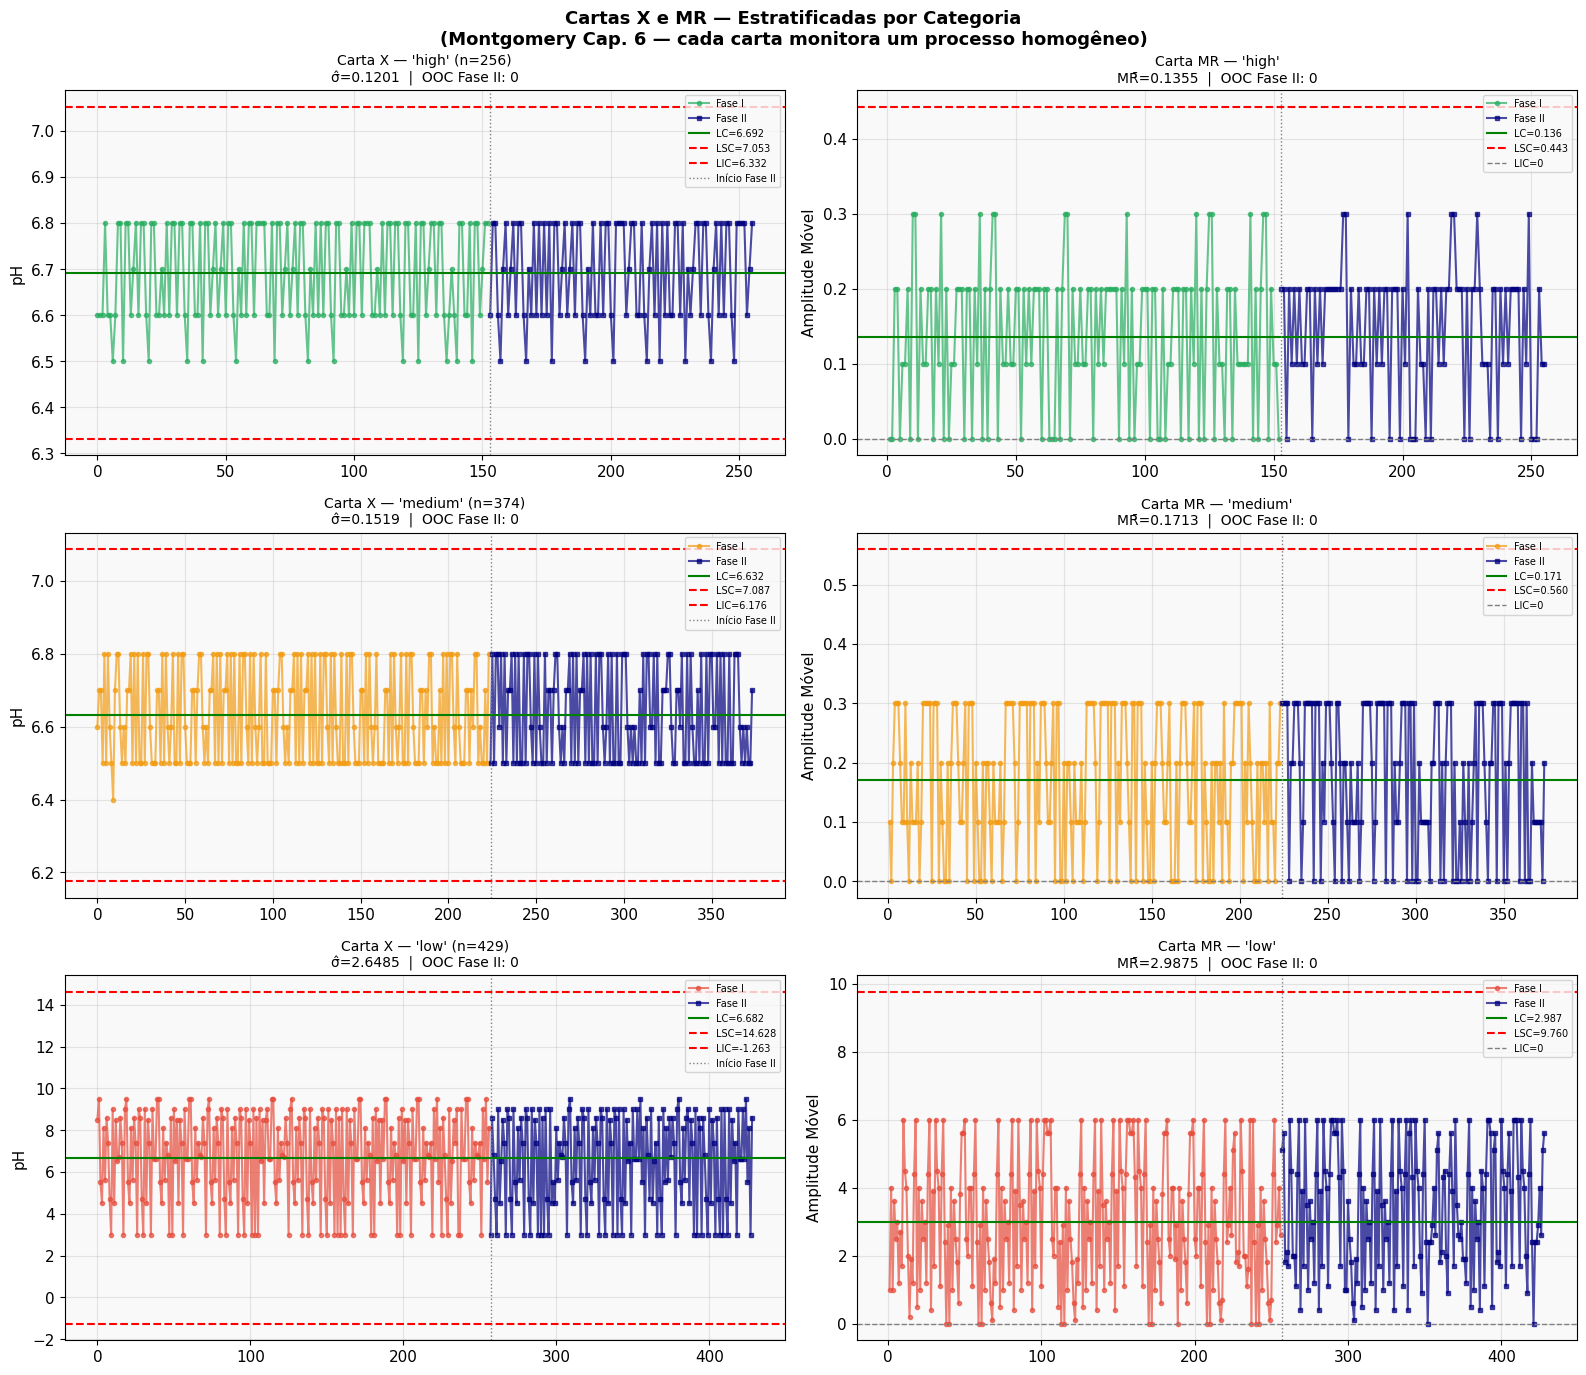


[Fig. 5 salva]


In [20]:
# Fase I (60% de cada categoria): estima X̄, MR̄ e σ̂ = MR̄/d₂
# Fase II (40% restantes): monitora o processo com os limites da Fase I
# Constantes de Shewhart para n=2 (Apêndice VI — Montgomery):
#   d₂ = 1.128  →  σ̂ = MR̄ / d₂
#   D₄ = 3.267  →  LSC(MR) = D₄ × MR̄
#   LIC(MR) = 0 (D₃ = 0 para n=2)

print("\n" + "=" * 70)
print("ETAPA 4: CARTAS DE CONTROLE X / MR — ESTRATIFICADAS")
print("Ref.: Montgomery Cap. 6, Seção 6.4")
print("=" * 70)

d2 = 1.128
D4 = 3.267

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
limites_por_grade = {}

print("\nLimites estabelecidos na Fase I (primeiros 60% de cada categoria):\n")

for idx, grade in enumerate(['high', 'medium', 'low']):
    sub = df_cep[df_cep['Grade'] == grade]['pH'].reset_index(drop=True)
    n_sub = len(sub)

    # Fase I: estimativas dos parâmetros do processo
    # X̄ é a linha central da carta X
    # MR̄ é a linha central da carta de amplitude móvel
    # σ̂ = MR̄/d₂ é o estimador robusto do desvio-padrão do processo
    n_f1 = int(n_sub * 0.6)
    sub_f1 = sub.iloc[:n_f1]
    mr_f1 = sub_f1.diff().abs().dropna()

    X_bar  = sub_f1.mean()
    MR_bar = mr_f1.mean()
    sigma  = MR_bar / d2

    # Limites ±3σ para carta X (Montgomery, eq. 6.4)
    lsc_X  = X_bar + 3 * sigma
    lic_X  = X_bar - 3 * sigma
    # Limite superior para carta MR (Montgomery, eq. 6.5)
    lsc_MR = D4 * MR_bar

    limites_por_grade[grade] = {
        'X_bar': X_bar, 'MR_bar': MR_bar, 'sigma': sigma,
        'lsc_X': lsc_X, 'lic_X': lic_X, 'lsc_MR': lsc_MR,
        'n_sub': n_sub, 'n_f1': n_f1
    }

    # Fase II: aplicação prospectiva dos limites
    # Pontos acima do LSC ou abaixo do LIC indicam causas especiais
    sub_f2 = sub.iloc[n_f1:]
    mr_all = sub.diff().abs()
    mr_f2  = mr_all.iloc[n_f1:]
    ooc_X  = sub_f2[(sub_f2 > lsc_X) | (sub_f2 < lic_X)]
    ooc_MR = mr_f2[mr_f2 > lsc_MR]

    print(f"  [{grade.upper()}]  X̄={X_bar:.4f}  σ̂={sigma:.4f}"
          f"  LSC={lsc_X:.4f}  LIC={lic_X:.4f}"
          f"  | OOC(X)={len(ooc_X)}  OOC(MR)={len(ooc_MR)}")

    cor = cores_cat[grade]

    # Carta X: monitora a localização do processo (média)
    # Pontos marcados com * indicam sinalização de causa especial na Fase II
    ax_X = axes[idx, 0]
    ax_X.plot(range(n_f1), sub_f1,
              'o-', color=cor, markersize=3, alpha=0.7, label='Fase I')
    ax_X.plot(range(n_f1, n_sub), sub_f2,
              's-', color='navy', markersize=3, alpha=0.7, label='Fase II')
    ax_X.axhline(X_bar,  color='green', lw=1.5, label=f'LC={X_bar:.3f}')
    ax_X.axhline(lsc_X,  color='red',   lw=1.5, ls='--', label=f'LSC={lsc_X:.3f}')
    ax_X.axhline(lic_X,  color='red',   lw=1.5, ls='--', label=f'LIC={lic_X:.3f}')
    ax_X.axvline(n_f1,   color='gray',  lw=1,   ls=':',  label='Início Fase II')
    if len(ooc_X) > 0:
        ax_X.plot(ooc_X.index, ooc_X.values,
                  'r*', markersize=10, zorder=5,
                  label=f'Fora de controle ({len(ooc_X)})')
    ax_X.set_title(f"Carta X — '{grade}' (n={n_sub})\n"
                   f"σ̂={sigma:.4f}  |  OOC Fase II: {len(ooc_X)}", fontsize=10)
    ax_X.set_ylabel("pH")
    ax_X.legend(fontsize=7, loc='upper right')

    # Carta MR: monitora a variabilidade do processo (dispersão)
    # Pontos acima do LSC indicam aumento súbito de variabilidade
    ax_MR = axes[idx, 1]
    ax_MR.plot(range(1, n_f1),     mr_all.iloc[1:n_f1],
               'o-', color=cor, markersize=3, alpha=0.7, label='Fase I')
    ax_MR.plot(range(n_f1, n_sub), mr_f2,
               's-', color='navy', markersize=3, alpha=0.7, label='Fase II')
    ax_MR.axhline(MR_bar, color='green', lw=1.5, label=f'LC={MR_bar:.3f}')
    ax_MR.axhline(lsc_MR, color='red',   lw=1.5, ls='--', label=f'LSC={lsc_MR:.3f}')
    ax_MR.axhline(0,       color='gray',  lw=1,   ls='--', label='LIC=0')
    ax_MR.axvline(n_f1,    color='gray',  lw=1,   ls=':')
    if len(ooc_MR) > 0:
        ax_MR.plot(ooc_MR.index, ooc_MR.values,
                   'r*', markersize=10, zorder=5,
                   label=f'Fora de controle ({len(ooc_MR)})')
    ax_MR.set_title(f"Carta MR — '{grade}'\n"
                    f"MR̄={MR_bar:.4f}  |  OOC Fase II: {len(ooc_MR)}", fontsize=10)
    ax_MR.set_ylabel("Amplitude Móvel")
    ax_MR.legend(fontsize=7, loc='upper right')

plt.suptitle(
    "Cartas X e MR — Estratificadas por Categoria\n"
    "(Montgomery Cap. 6 — cada carta monitora um processo homogêneo)",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("fig5_cartas_estratificadas.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n[Fig. 5 salva]")

**Etapa 5: Índices de Capacidade do Processo**

Com os limites de controle estabelecidos, deve-se avaliar se o processo é capaz de atender às especificações normativas. Os limites de especificação adotados são LIE = 6,6 e LSE = 6,8, conforme a Instrução Normativa 76/2018 do MAPA para leite pasteurizado.

São calculados três índices para cada categoria: Cp (capacidade potencial, sem considerar o centramento), Cpk (capacidade real, leva em conta o centramento da média em relação aos limites) e Cpm (índice de Taguchi, que penaliza o desvio em relação ao valor nominal). Os três índices são interpretados segundo a Tabela 8.3 do Montgomery: Cpk ≥ 1,33 indica processo capaz; Cpk < 1,00 exige ação imediata.


ETAPA 4: CAPACIDADE DO PROCESSO
Ref.: Montgomery Cap. 8 | Limites: IN 76/2018 MAPA

Limites de Especificação (IN 76/2018 MAPA):
  LIE=6.6  |  LSE=6.8  |  Tolerância=0.20  |  Nominal=6.699999999999999

Categoria        X̄       σ̂       Cp      Cpu      Cpl      Cpk
--------------------------------------------------------------
high         6.6922   0.1201    0.277    0.299    0.256    0.256
medium       6.6317   0.1519    0.219    0.369    0.070    0.070
low          6.6821   2.6485    0.013    0.015    0.010    0.010

Critério Montgomery Cap. 8, Tabela 8.3:
  Cpk ≥ 1.33 → processo capaz  |  Cpk < 1.00 → ação imediata
  high    : Cpk=0.256  → NÃO CAPAZ ✗ — ação necessária
  medium  : Cpk=0.070  → NÃO CAPAZ ✗ — ação necessária
  low     : Cpk=0.010  → NÃO CAPAZ ✗ — ação necessária


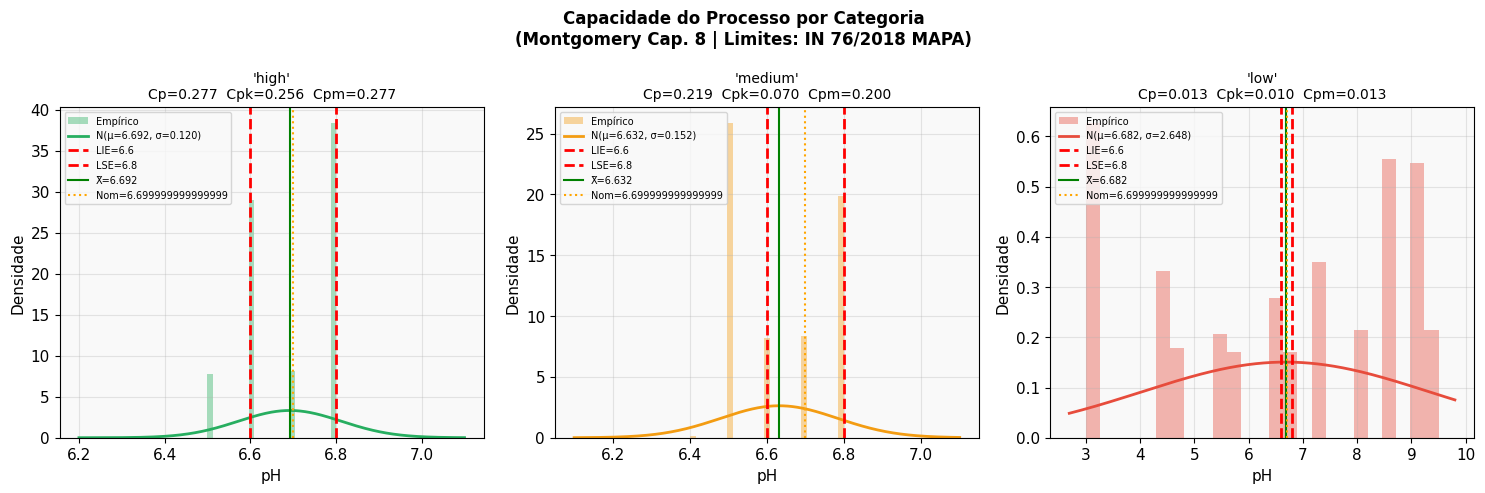


[Fig. 6 salva]


In [21]:
# Limites de especificação: IN 76/2018 MAPA — leite pasteurizado
#   LIE = 6.6  (pH mínimo aceitável)
#   LSE = 6.8  (pH máximo aceitável)
#
# Cp  = (LSE - LIE) / (6σ̂)         → capacidade potencial
# Cpu = (LSE - X̄)  / (3σ̂)         → margem até o limite superior
# Cpl = (X̄  - LIE) / (3σ̂)         → margem até o limite inferior
# Cpk = min(Cpu, Cpl)               → capacidade real (pior lado)
# Cpm = (LSE - LIE) / (6τ)          → índice de Taguchi
#   onde τ = √(σ̂² + (X̄ - nominal)²)

print("\n" + "=" * 70)
print("ETAPA 4: CAPACIDADE DO PROCESSO")
print("Ref.: Montgomery Cap. 8 | Limites: IN 76/2018 MAPA")
print("=" * 70)

LSE = 6.8
LIE = 6.6
nominal    = (LSE + LIE) / 2
tolerancia = LSE - LIE

print(f"\nLimites de Especificação (IN 76/2018 MAPA):")
print(f"  LIE={LIE}  |  LSE={LSE}  |  Tolerância={tolerancia:.2f}"
      f"  |  Nominal={nominal}")

print("\n{:<10} {:>8} {:>8} {:>8} {:>8} {:>8} {:>8}".format(
    "Categoria", "X̄", "σ̂", "Cp", "Cpu", "Cpl", "Cpk"))
print("-" * 62)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
capacidade = {}

for idx, grade in enumerate(['high', 'medium', 'low']):
    lim  = limites_por_grade[grade]
    Xbar = lim['X_bar']
    sig  = lim['sigma']

    Cp  = tolerancia / (6 * sig)
    Cpu = (LSE  - Xbar) / (3 * sig)
    Cpl = (Xbar - LIE)  / (3 * sig)
    Cpk = min(Cpu, Cpl)
    tau = np.sqrt(sig**2 + (Xbar - nominal)**2)
    Cpm = tolerancia / (6 * tau)

    capacidade[grade] = dict(Cp=Cp, Cpu=Cpu, Cpl=Cpl, Cpk=Cpk, Cpm=Cpm)

    print("{:<10} {:>8.4f} {:>8.4f} {:>8.3f} {:>8.3f} {:>8.3f} {:>8.3f}".format(
        grade, Xbar, sig, Cp, Cpu, Cpl, Cpk))

    # Gráfico de capacidade: histograma empírico + curva normal ajustada
    # com os limites de especificação sobrepostos.
    # Área fora de [LIE, LSE] representa produção fora da especificação.
    dados_cat = df_cep[df_cep['Grade'] == grade]['pH']
    x_range = np.linspace(dados_cat.min() - 0.3, dados_cat.max() + 0.3, 400)
    axes[idx].hist(dados_cat, bins=25, density=True, alpha=0.4,
                   color=cores_cat[grade], label='Empírico')
    axes[idx].plot(x_range, stats.norm.pdf(x_range, Xbar, sig),
                   color=cores_cat[grade], lw=2,
                   label=f'N(μ={Xbar:.3f}, σ={sig:.3f})')
    axes[idx].axvline(LIE,     color='red',    lw=2, ls='--', label=f'LIE={LIE}')
    axes[idx].axvline(LSE,     color='red',    lw=2, ls='--', label=f'LSE={LSE}')
    axes[idx].axvline(Xbar,    color='green',  lw=1.5, ls='-',  label=f'X̄={Xbar:.3f}')
    axes[idx].axvline(nominal, color='orange', lw=1.5, ls=':', label=f'Nom={nominal}')
    axes[idx].set_title(
        f"'{grade}'\nCp={Cp:.3f}  Cpk={Cpk:.3f}  Cpm={Cpm:.3f}", fontsize=10)
    axes[idx].set_xlabel("pH")
    axes[idx].set_ylabel("Densidade")
    axes[idx].legend(fontsize=7)

# Interpretação segundo Montgomery Cap. 8, Tabela 8.3
print("\nCritério Montgomery Cap. 8, Tabela 8.3:")
print("  Cpk ≥ 1.33 → processo capaz  |  Cpk < 1.00 → ação imediata")
for grade, cap in capacidade.items():
    cpk = cap['Cpk']
    if cpk >= 1.33:
        status = "CAPAZ ✓"
    elif cpk >= 1.00:
        status = "Marginalmente capaz"
    else:
        status = "NÃO CAPAZ ✗ — ação necessária"
    print(f"  {grade:8s}: Cpk={cpk:.3f}  → {status}")

plt.suptitle(
    "Capacidade do Processo por Categoria\n"
    "(Montgomery Cap. 8 | Limites: IN 76/2018 MAPA)",
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("fig6_capacidade.png", dpi=150)
plt.show()
print("\n[Fig. 6 salva]")

**Etapa 6: Diagnóstico Final e Plano de Ação**

A última etapa consolida todos os resultados e propõe um Plano de Ação para Fora de Controle, o PAFC.

O PAFC é estruturado em quatro níveis: investigação imediata dos lotes sinalizados, ação corretiva no processo, ação preventiva de longo prazo e revisão periódica dos limites. Montgomery recomenda revisar os limites de controle a cada 25 a 50 novas amostras. Para processos onde a Fase II exige maior sensibilidade a pequenos deslocamentos, o próprio Montgomery sugere migrar para cartas CUSUM ou MMEP, abordadas no Capítulo 9.

In [23]:
# Todos os valores são puxados das variáveis já calculadas.

print("\n" + "=" * 70)
print("RESUMO EXECUTIVO — DMAMC")
print("=" * 70)

print(f"""
  D — DEFINIR
    CTQ : pH
    Dataset : {df.shape[0]} amostras
    Categorias : low={df['Grade'].value_counts()['low']}  |  medium={df['Grade'].value_counts()['medium']}  |  high={df['Grade'].value_counts()['high']}

  M — MEDIR
    pH médio por categoria:
      high   → {df[df['Grade']=='high']['pH'].mean():.3f}
      medium → {df[df['Grade']=='medium']['pH'].mean():.3f}
      low    → {df[df['Grade']=='low']['pH'].mean():.3f}
    Médias distintas confirmam mistura de subpopulações.

  A — ANALISAR
    CTQ mais importante (Random Forest): {importances.idxmax().upper()}
    Acurácia CV-5: {cv_scores.mean():.1%} → dataset sintético com regras determinísticas.
    Importâncias usadas como priorização de CTQs, não como causa-raiz.

  M — MELHORAR
    Ação estrutural: estratificar monitoramento por categoria.
    Sem estratificação, σ̂ seria inflado pela variação entre grupos,
    tornando as cartas cegas a desvios reais dentro de cada processo.

  C — CONTROLAR
    Normalidade:
      Todas as categorias → não-normal pelo Shapiro-Wilk.
      Causa identificada: pH discretizado por construção do dataset.
      Procedimento adotado: aproximação normal (Montgomery Cap. 8).

    Cartas X/MR estratificadas — limites (Fase I):
      high:   σ̂={limites_por_grade['high']['sigma']:.4f}   LSC={limites_por_grade['high']['lsc_X']:.4f}   LIC={limites_por_grade['high']['lic_X']:.4f}
      medium: σ̂={limites_por_grade['medium']['sigma']:.4f}   LSC={limites_por_grade['medium']['lsc_X']:.4f}   LIC={limites_por_grade['medium']['lic_X']:.4f}
      low:    σ̂={limites_por_grade['low']['sigma']:.4f}   LSC={limites_por_grade['low']['lsc_X']:.4f}   LIC={limites_por_grade['low']['lic_X']:.4f}

    Capacidade (LIE={LIE} | LSE={LSE} — IN 76/2018 MAPA):
      high:   Cp={capacidade['high']['Cp']:.3f}   Cpk={capacidade['high']['Cpk']:.3f}
      medium: Cp={capacidade['medium']['Cp']:.3f}   Cpk={capacidade['medium']['Cpk']:.3f}
      low:    Cp={capacidade['low']['Cp']:.3f}   Cpk={capacidade['low']['Cpk']:.3f}
    Todos com Cpk < 1.33 → processo não capaz dentro dos limites MAPA.
""")

print("=" * 70)
print("PLANO DE AÇÃO E FOCO DE CONTROLE (PAFC)")
print("Ref.: Montgomery Cap. 6 e Cap. 9")
print("=" * 70)

print(f"""
  NÍVEL 1 — INVESTIGAÇÃO IMEDIATA
    Acionar para cada ponto fora de controle sinalizado nas cartas X e MR.
    Isolar o lote correspondente e coletar amostras adicionais para
    confirmar se a causa especial persiste ou foi pontual.
    Registrar: horário, turno, equipamento, fornecedor e condições
    de temperatura no momento da sinalização.

  NÍVEL 2 — AÇÃO CORRETIVA NO PROCESSO
    Após identificação da causa especial, eliminar a fonte de variação
    e recalcular os limites da Fase I excluindo os pontos afetados.
    Para o processo não capaz (Cpk < 1.33 em todas as categorias):
    investigar as fontes que inflam σ̂ — candidatos principais são
    variação de temperatura (segunda CTQ no ranking do RF) e resolução
    do instrumento de medição de pH.
    Meta: reduzir σ̂ até Cpk ≥ 1.33, equivalente a desvio-padrão
    máximo de {(LSE - LIE) / (6 * 1.33):.4f} para a tolerância atual (IN 76/2018 MAPA).

  NÍVEL 3 — AÇÃO PREVENTIVA DE LONGO PRAZO
    Expandir o monitoramento para as próximas CTQs no ranking:
    {importances.sort_values(ascending=False).index[1].upper()} e
    {importances.sort_values(ascending=False).index[2].upper()},
    seguindo o mesmo protocolo de Fase I/II aplicado ao pH.
    Em processo real: substituir sensor de pH com resolução de 0,1
    por sensor com resolução de 0,01 — eliminaria a discretização
    identificada nos Q-Q plots e tornaria desnecessária a aproximação normal.
    Para maior sensibilidade a pequenos deslocamentos de média na Fase II,
    Montgomery (Cap. 9) recomenda migrar das cartas X/MR para cartas
    CUSUM ou MMEP, mais eficientes na detecção de desvios de até 1,5σ.

  NÍVEL 4 — REVISÃO PERIÓDICA DOS LIMITES
    Montgomery recomenda revisar os limites de controle a cada 25 a 50
    novas amostras. A cada revisão: verificar se X̄ e σ̂ se mantêm
    estáveis, recalcular Cp e Cpk com os novos dados, e avaliar se
    a estratificação por categoria ainda é necessária ou se o processo
    convergiu para uma faixa de pH homogênea.
    Para implantação em linha de produção real, toda a metodologia
    deste MVP deve ser revalidada com no mínimo 100 amostras coletadas
    em condições estáveis antes de qualquer decisão operacional.
""")

print("Análise concluída. Figuras salvas: fig1 a fig6.")


RESUMO EXECUTIVO — DMAMC

  D — DEFINIR
    CTQ : pH
    Dataset : 1059 amostras
    Categorias : low=429  |  medium=374  |  high=256

  M — MEDIR
    pH médio por categoria:
      high   → 6.693
      medium → 6.635
      low    → 6.589
    Médias distintas confirmam mistura de subpopulações.

  A — ANALISAR
    CTQ mais importante (Random Forest): PH
    Acurácia CV-5: 99.6% → dataset sintético com regras determinísticas.
    Importâncias usadas como priorização de CTQs, não como causa-raiz.

  M — MELHORAR
    Ação estrutural: estratificar monitoramento por categoria.
    Sem estratificação, σ̂ seria inflado pela variação entre grupos,
    tornando as cartas cegas a desvios reais dentro de cada processo.

  C — CONTROLAR
    Normalidade:
      Todas as categorias → não-normal pelo Shapiro-Wilk.
      Causa identificada: pH discretizado por construção do dataset.
      Procedimento adotado: aproximação normal (Montgomery Cap. 8).

    Cartas X/MR estratificadas — limites (Fase I):
 